In [ ]:
!pip install umap-learn matplotlib

# UMAP Visualization of FinDER Corpus Embeddings

**Goal**: Visualize the 1024-dim e5-large-v2 embeddings in 2D using UMAP.
We select 200 maximally diverse "boundary" points via Max-Sum Angular Diversification,
then overlay them on the full corpus to show how they capture the shape of the embedding space.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import umap

# Load pre-encoded corpus embeddings
CORPUS_EMBEDDINGS_PATH = "./encoded_data/corpus_embeddings.pkl"
QUERY_EMBEDDINGS_PATH = "./encoded_data/query_embeddings.pkl"

with open(CORPUS_EMBEDDINGS_PATH, 'rb') as f:
    corpus_data = pickle.load(f)

with open(QUERY_EMBEDDINGS_PATH, 'rb') as f:
    query_data = pickle.load(f)

corpus_embeddings = corpus_data['embeddings']
corpus_ids = corpus_data['ids']
query_embeddings = query_data['embeddings']
query_ids = query_data['ids']

print(f"Corpus embeddings: {corpus_embeddings.shape}")
print(f"Query embeddings: {query_embeddings.shape}")

/opt/homebrew/anaconda3/envs/finrag/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Corpus embeddings: (13867, 1024)
Query embeddings: (216, 1024)


## Max-Sum Angular Diversification
Select 200 boundary points that are maximally spread out in embedding space (maximize sum of pairwise angular distances).

In [2]:
from typing import Iterator, Tuple, List, Optional

# --- Normalization + batching ---

def l2_normalize_batch(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)

def iter_batches(X: np.ndarray, batch_size: int) -> Iterator[Tuple[int, np.ndarray]]:
    n = X.shape[0]
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        yield start, X[start:end]

# --- Angular distance via LUT acos ---

def make_acos_lut(bins: int = 16384) -> np.ndarray:
    xs = np.linspace(-1.0, 1.0, bins, dtype=np.float32)
    return np.arccos(xs).astype(np.float32)

def acos_lut(dots: np.ndarray, lut: np.ndarray) -> np.ndarray:
    dots = np.clip(dots, -1.0, 1.0)
    bins = lut.shape[0]
    idx = ((dots + 1.0) * 0.5 * (bins - 1)).astype(np.int32)
    return lut[idx]

# --- Candidate pool builder ---

def build_candidate_indices(
    X: np.ndarray,
    M_random: int = 200_000,
    num_dirs: int = 64,
    per_dir: int = 20,
    stream_batch: int = 200_000,
    random_state: int = 0,
) -> np.ndarray:
    rng = np.random.default_rng(random_state)
    n, d = X.shape

    if M_random >= n:
        rand_idx = np.arange(n, dtype=np.int64)
    else:
        rand_idx = rng.choice(n, size=M_random, replace=False).astype(np.int64)

    R = rng.normal(size=(num_dirs, d)).astype(np.float32)
    R /= np.maximum(np.linalg.norm(R, axis=1, keepdims=True), 1e-12)

    best_max_vals = np.full((num_dirs, per_dir), -np.inf, dtype=np.float32)
    best_max_idx  = np.full((num_dirs, per_dir), -1, dtype=np.int64)
    best_min_vals = np.full((num_dirs, per_dir), +np.inf, dtype=np.float32)
    best_min_idx  = np.full((num_dirs, per_dir), -1, dtype=np.int64)

    for start, Xb in iter_batches(X, stream_batch):
        Ub = l2_normalize_batch(Xb)
        proj = Ub @ R.T
        idxs = np.arange(start, start + Ub.shape[0], dtype=np.int64)
        B = Ub.shape[0]

        for j in range(num_dirs):
            col = proj[:, j]
            if per_dir < B:
                top_pos = np.argpartition(col, -per_dir)[-per_dir:]
                bot_pos = np.argpartition(col,  per_dir)[:per_dir]
            else:
                top_pos = np.arange(B)
                bot_pos = np.arange(B)

            cand_vals = np.concatenate([best_max_vals[j], col[top_pos].astype(np.float32)])
            cand_idx  = np.concatenate([best_max_idx[j],  idxs[top_pos]])
            keep = np.argpartition(cand_vals, -per_dir)[-per_dir:]
            best_max_vals[j] = cand_vals[keep]
            best_max_idx[j]  = cand_idx[keep]

            cand_vals = np.concatenate([best_min_vals[j], col[bot_pos].astype(np.float32)])
            cand_idx  = np.concatenate([best_min_idx[j],  idxs[bot_pos]])
            keep = np.argpartition(cand_vals,  per_dir)[:per_dir]
            best_min_vals[j] = cand_vals[keep]
            best_min_idx[j]  = cand_idx[keep]

    extreme_idx = np.concatenate([best_max_idx.ravel(), best_min_idx.ravel()])
    extreme_idx = extreme_idx[extreme_idx >= 0]
    return np.unique(np.concatenate([rand_idx, extreme_idx]).astype(np.int64))


def load_candidates_normalized(X: np.ndarray, cand_idx: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    cand_idx = np.unique(cand_idx.astype(np.int64))
    cand_idx.sort()
    C = np.asarray(X[cand_idx], dtype=np.float32)
    U = l2_normalize_batch(C)
    return U, cand_idx

# --- Greedy max-sum diversification (angular) ---

def greedy_max_sum_angular(
    U: np.ndarray, k: int,
    lut: Optional[np.ndarray] = None,
    seed: str = "farthest2",
    dot_batch: int = 200_000,
    random_state: int = 0,
) -> List[int]:
    rng = np.random.default_rng(random_state)
    M = U.shape[0]
    if k <= 0:
        return []
    if k >= M:
        return list(range(M))

    if lut is None:
        lut = make_acos_lut(16384)
    dist_fn = lambda dots: acos_lut(dots, lut)

    selected = np.zeros(M, dtype=bool)
    score = np.zeros(M, dtype=np.float32)

    def add_point(p: int) -> None:
        selected[p] = True
        up = U[p]
        for i in range(0, M, dot_batch):
            j = min(i + dot_batch, M)
            score[i:j] += dist_fn(U[i:j] @ up).astype(np.float32)
        score[selected] = -np.inf

    S: List[int] = []
    if seed == "farthest2":
        p0 = 0
        d0 = dist_fn(U @ U[p0])
        p1 = int(np.argmax(d0))
        S.append(p1)
        add_point(p1)
        if k > 1:
            d1 = dist_fn(U @ U[p1])
            p2 = int(np.argmax(d1))
            if not selected[p2]:
                S.append(p2)
                add_point(p2)
        S = S[:k]

    # Recompute score from S
    score[:] = 0.0
    selected[:] = False
    selected[np.array(S, dtype=np.int64)] = True
    for p in S:
        up = U[p]
        for i in range(0, M, dot_batch):
            j = min(i + dot_batch, M)
            score[i:j] += dist_fn(U[i:j] @ up).astype(np.float32)
    score[selected] = -np.inf

    while len(S) < k:
        p = int(np.argmax(score))
        S.append(p)
        add_point(p)
        if len(S) % 50 == 0:
            print(f"  Selected {len(S)}/{k} diverse points...")

    return S

# --- End-to-end API ---

def select_diverse_subset(
    X: np.ndarray, k: int,
    M_random: int = 200_000,
    num_dirs: int = 64,
    per_dir: int = 20,
    stream_batch: int = 200_000,
    random_state: int = 0,
) -> np.ndarray:
    """Returns indices (in the original dataset) of k maximally diverse points."""
    print(f"Building candidate pool from {X.shape[0]} vectors...")
    cand_idx = build_candidate_indices(
        X, M_random=M_random, num_dirs=num_dirs, per_dir=per_dir,
        stream_batch=stream_batch, random_state=random_state,
    )
    print(f"Candidate pool size: {cand_idx.shape[0]}")

    Uc, cand_sorted = load_candidates_normalized(X, cand_idx)
    lut = make_acos_lut(16384)

    print(f"Running greedy max-sum angular diversification for k={k}...")
    S = greedy_max_sum_angular(
        Uc, k, lut=lut, seed="farthest2",
        dot_batch=200_000, random_state=random_state,
    )

    return cand_sorted[np.array(S, dtype=np.int64)]

print("Diversification functions defined.")

Diversification functions defined.


In [3]:
# Select 200 maximally diverse boundary points from corpus embeddings
K_DIVERSE = 200

diverse_indices = select_diverse_subset(
    corpus_embeddings,
    k=K_DIVERSE,
    M_random=min(200_000, corpus_embeddings.shape[0]),  # cap at corpus size
    num_dirs=64,
    per_dir=20,
    random_state=42,
)

print(f"\nSelected {len(diverse_indices)} diverse boundary points from {corpus_embeddings.shape[0]} corpus documents")

Building candidate pool from 13867 vectors...
Candidate pool size: 13867
Running greedy max-sum angular diversification for k=200...
  Selected 50/200 diverse points...
  Selected 100/200 diverse points...
  Selected 150/200 diverse points...
  Selected 200/200 diverse points...

Selected 200 diverse boundary points from 13867 corpus documents


## UMAP Projection
Reduce all corpus + query embeddings from 1024-dim to 2D using UMAP, then visualize with the 200 boundary points highlighted.

In [4]:
# Combine corpus + query embeddings for a joint UMAP projection
all_embeddings = np.vstack([corpus_embeddings, query_embeddings])
n_corpus = corpus_embeddings.shape[0]
n_query = query_embeddings.shape[0]

print(f"Running UMAP on {all_embeddings.shape[0]} vectors ({n_corpus} corpus + {n_query} queries)...")
print("This may take a few minutes...")

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
)

umap_2d = reducer.fit_transform(all_embeddings)

# Split back into corpus and query projections
corpus_2d = umap_2d[:n_corpus]
query_2d = umap_2d[n_corpus:]

# Get the 2D coordinates of the 200 diverse boundary points
diverse_2d = corpus_2d[diverse_indices]

print(f"UMAP projection complete: {umap_2d.shape}")

Running UMAP on 14083 vectors (13867 corpus + 216 queries)...
This may take a few minutes...


/opt/homebrew/anaconda3/envs/finrag/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP projection complete: (14083, 2)


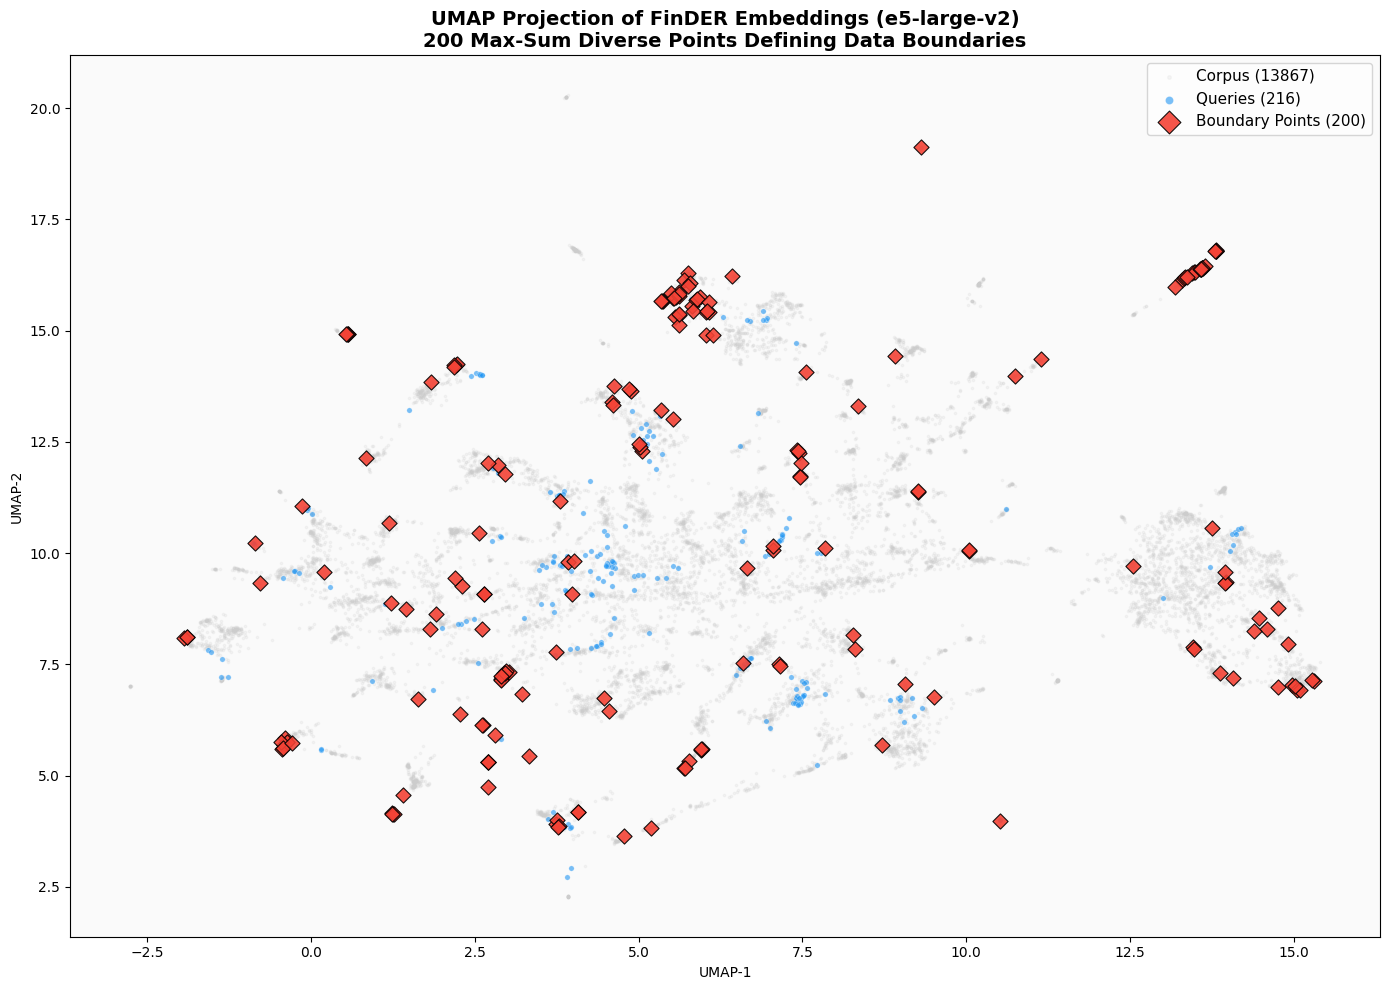

Saved: umap_boundary_visualization.png


In [5]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot all corpus points (light gray background)
ax.scatter(corpus_2d[:, 0], corpus_2d[:, 1],
           s=3, alpha=0.15, c='#cccccc', label=f'Corpus ({n_corpus})')

# Plot query points (blue)
ax.scatter(query_2d[:, 0], query_2d[:, 1],
           s=15, alpha=0.6, c='#2196F3', edgecolors='white', linewidths=0.3,
           label=f'Queries ({n_query})')

# Plot 200 diverse boundary points (red, prominent)
ax.scatter(diverse_2d[:, 0], diverse_2d[:, 1],
           s=60, alpha=0.9, c='#F44336', edgecolors='black', linewidths=0.8,
           marker='D', label=f'Boundary Points ({K_DIVERSE})')

ax.set_title('UMAP Projection of FinDER Embeddings (e5-large-v2)\n'
             f'200 Max-Sum Diverse Points Defining Data Boundaries',
             fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend(loc='upper right', fontsize=11, markerscale=1.5)
ax.set_facecolor('#fafafa')
fig.tight_layout()
plt.savefig('umap_boundary_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: umap_boundary_visualization.png")

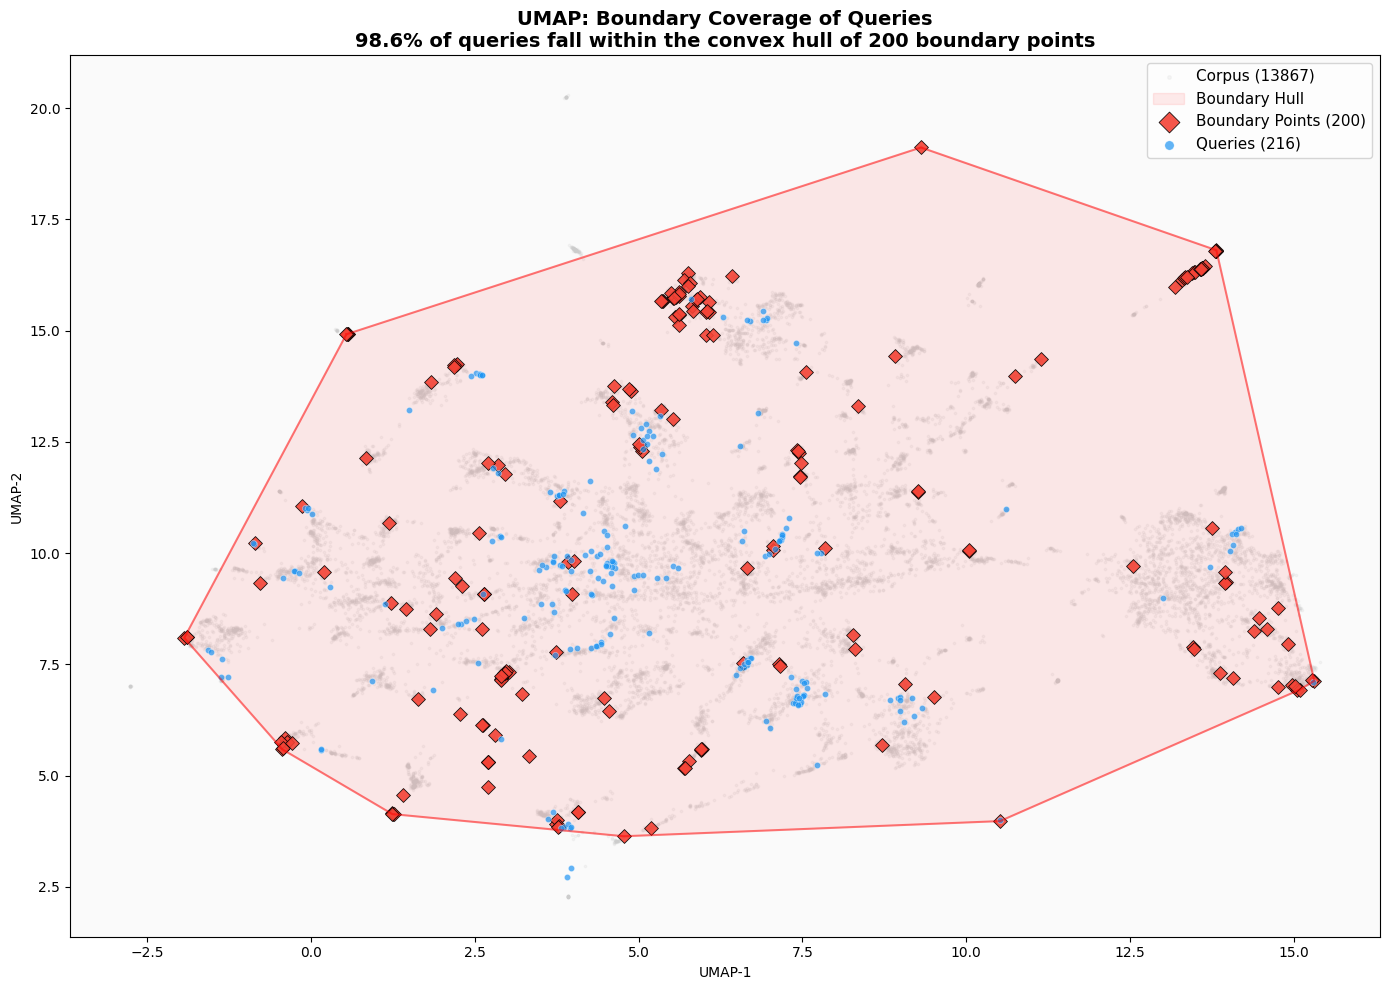

Queries inside boundary hull: 213/216 (98.6%)
Saved: umap_boundary_hull.png


In [6]:
from scipy.spatial import ConvexHull

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot all corpus points
ax.scatter(corpus_2d[:, 0], corpus_2d[:, 1],
           s=3, alpha=0.15, c='#cccccc', label=f'Corpus ({n_corpus})')

# Convex hull of the 200 diverse points
hull = ConvexHull(diverse_2d)
hull_pts = np.append(hull.vertices, hull.vertices[0])  # close the polygon
ax.fill(diverse_2d[hull_pts, 0], diverse_2d[hull_pts, 1],
        alpha=0.08, color='red', label='Boundary Hull')
ax.plot(diverse_2d[hull_pts, 0], diverse_2d[hull_pts, 1],
        'r-', linewidth=1.5, alpha=0.5)

# Overlay boundary points
ax.scatter(diverse_2d[:, 0], diverse_2d[:, 1],
           s=50, alpha=0.9, c='#F44336', edgecolors='black', linewidths=0.6,
           marker='D', label=f'Boundary Points ({K_DIVERSE})')

# Query points on top
ax.scatter(query_2d[:, 0], query_2d[:, 1],
           s=20, alpha=0.7, c='#2196F3', edgecolors='white', linewidths=0.3,
           label=f'Queries ({n_query})')

# Count queries inside vs outside the hull
from scipy.spatial import Delaunay
hull_delaunay = Delaunay(diverse_2d[hull.vertices])
inside_mask = hull_delaunay.find_simplex(query_2d) >= 0
pct_covered = inside_mask.sum() / n_query * 100

ax.set_title(f'UMAP: Boundary Coverage of Queries\n'
             f'{pct_covered:.1f}% of queries fall within the convex hull of {K_DIVERSE} boundary points',
             fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend(loc='upper right', fontsize=11, markerscale=1.5)
ax.set_facecolor('#fafafa')
fig.tight_layout()
plt.savefig('umap_boundary_hull.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Queries inside boundary hull: {inside_mask.sum()}/{n_query} ({pct_covered:.1f}%)")
print("Saved: umap_boundary_hull.png")

In [7]:
# --- Correctness Check ---
# The 200 diverse points should have HIGHER avg pairwise angular distance
# than 200 random points. If not, the algorithm is not working.

rng = np.random.default_rng(0)
random_indices = rng.choice(corpus_embeddings.shape[0], size=200, replace=False)

def avg_pairwise_angular(embeddings, indices):
    vecs = l2_normalize_batch(embeddings[indices])
    dots = vecs @ vecs.T
    angles = np.arccos(np.clip(dots, -1, 1))
    # Upper triangle only (no self-distances)
    upper = angles[np.triu_indices(len(indices), k=1)]
    return float(np.mean(upper))

avg_diverse = avg_pairwise_angular(corpus_embeddings, diverse_indices)
avg_random  = avg_pairwise_angular(corpus_embeddings, random_indices)

print(f"Avg pairwise angular distance:")
print(f"  200 diverse (boundary) points : {avg_diverse:.4f} rad  ({np.degrees(avg_diverse):.2f}°)")
print(f"  200 random  points            : {avg_random:.4f} rad  ({np.degrees(avg_random):.2f}°)")
print(f"  Improvement                   : {(avg_diverse / avg_random - 1)*100:.1f}%")
print()
if avg_diverse > avg_random:
    print("✅ CORRECT — diverse points are more spread out than random")
else:
    print("❌ Something is wrong — random beats diverse")

Avg pairwise angular distance:
  200 diverse (boundary) points : 0.8110 rad  (46.47°)
  200 random  points            : 0.7009 rad  (40.16°)
  Improvement                   : 15.7%

✅ CORRECT — diverse points are more spread out than random
